---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми курсу:</b></p>
<ul style="text-align: left;">
  <li>Прилади із зарядним зв'язком (ПЗЗ)</li>
  <li>Диністори, тиристори та симістори</li>
  <li>Способи вмикання/вимикання тиристорів</li>
  <li>IGBT-транзистори</li>
  <li>Фоторезистори, фотодіоди, оптрони</li>
  <li>Терморезистори та варістори</li>
  <li>Світлодіоди</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<img src="Teacher.jpg" width="150" style="border-radius: 50%; display: block; margin: 10px auto;"/>
<p style="text-align: center;"><b>Пахалюк Богдан Петрович</b></p>
<p style="text-align: center;">Доктор філософії</p>
<p style="text-align: center;">Кафедра РТВС</p>
<hr/>
<p style="text-align: center; font-size: 0.9em;">Частина 3 з 3: Інші напівпровідникові прилади</p>
</div>
    </th>
  </tr>
</table>

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Прилади із зарядним зв'язком (ПЗЗ)](#ccd)
* [Тиристорні прилади](#thyristor-family)
    * [Диністор](#dinistor)
    * [Тиристор з керуючим електродом (тринистор)](#scr-thyristor)
    * [Вольт-амперна характеристика тиристора](#thyristor-vi-curve)
    * [Симетричні тиристори (симістори, TRIAC)](#triac)
    * [Способи вмикання та вимикання тиристорів](#thyristor-switching)
* [IGBT-транзистори](#igbt)
* [Оптоелектронні прилади](#optoelectronics)
    * [Фоторезистори](#photoresistor)
    * [Фотодіоди](#photodiode)
    * [Оптрони](#optocoupler)
* [Терморезистори, варістори та світлодіоди](#thermal-varistor-led)
    * [Терморезистори](#thermistor)
    * [Варістори](#varistor)
    * [Світлодіоди](#led)
* [Підсумок курсу](#course-summary)

---

In [1]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import matplotlib.patches as mpatches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print("schemdraw не встановлено (pip install schemdraw)")

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

/home/bp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Прилади із зарядним зв'язком (ПЗЗ) <a class="anchor" id="ccd"></a>

**Прилад із зарядним зв'язком** (ПЗЗ, англ. *charge-coupled device*, CCD) — це напівпровідниковий прилад на основі структури **метал-діелектрик-напівпровідник** (МДН, або MOS), у якому інформація зберігається у вигляді **пакетів нерівноважного заряду**, локалізованих у потенціальних ямах поблизу поверхні напівпровідника, а зчитування здійснюється шляхом **напрямленого перенесення** цих пакетів вздовж поверхні за допомогою послідовності тактових імпульсів.

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати утворення потенціальної ями в МДН-структурі при подачі керуючої напруги
> - Описувати механізм зберігання та перенесення зарядних пакетів
> - Пояснювати принцип тактового (фазового) керування перенесенням заряду
> - Наводити області застосування ПЗЗ

</div>

**Структура елементарної комірки.** Основою ПЗЗ є **МДН-конденсатор**: на кремнієву підкладку (наприклад, слабколегований p-Si) нанесено тонкий шар діелектрика SiO₂, а поверх нього — металевий або полікремнієвий електрод (затвор). Якщо до затвора прикласти позитивну відносно підкладки напругу, основні носії (дірки) відтісняються вглиб підкладки, утворюючи **область збіднення**, а біля поверхні під затвором виникає **потенціальна яма** для неосновних носіїв (електронів) — це так званий режим **глибокого невиродженого збіднення** (deep depletion), що використовується саме тому, що яма встигає заповнитися лише за рахунок injected/зібраного заряду, а не за рахунок теплової генерації.

Заряд, що потрапив у яму (наприклад, фотогенерований під дією світла, або інжектований через вхідний діод), утримується там, поки прикладена напруга не знята. Глибина ями — а отже, і максимальний обсяг заряду, який можна в ній зберегти, — пропорційна напрузі на затворі.

### Перенесення заряду: тактове (фазове) керування

Щоб зчитати накопичений заряд, його необхідно **перемістити** вздовж поверхні до вихідного пристрою. Для цього ряд сусідніх електродів об'єднують у групи, кожна з яких живиться від свого тактового генератора (найпоширеніша схема — **трифазна**, $\varphi_1, \varphi_2, \varphi_3$). Подаючи на сусідній електрод вищу напругу, ніж на електроді, де зараз знаходиться заряд, створюють глибшу яму поруч; заряд, за законом мінімізації електростатичної енергії, **перетікає** в глибшу яму. Послідовно і циклічно змінюючи напруги на трьох групах електродів (класична часова діаграма трифазного тактування), пакет заряду **крок за кроком** переміщується вздовж усього регістру зсуву до вихідного каскаду, де перетворюється на струм або напругу.

### 📖 Ключові поняття

| Поняття | Пояснення |
|---------|-----------|
| **МДН-конденсатор** | Базовий елемент ПЗЗ: метал (затвор) – діелектрик (SiO₂) – напівпровідник |
| **Потенціальна яма** | Область під затвором, куди "стікають" неосновні носії при збідненні |
| **Зарядний пакет** | Кількість заряду, накопиченого в потенціальній ямі — носій інформації |
| **Тактування (clocking)** | Циклічна зміна напруг на групах електродів для напрямленого перенесення заряду |
| **Ефективність перенесення** | Частка заряду, яка успішно передається за один такт (у сучасних ПЗЗ $>0{,}9999$) |

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Прилад із зарядним зв'язком винайшли **Віллард Бойл** і **Джордж Сміт** у лабораторії Bell Labs у 1969 р. — спочатку як пристрій пам'яті, альтернативу магнітним лініям затримки. Лише згодом усвідомили його головну перспективу — **перетворення оптичного зображення в електричний сигнал**, що зробило ПЗЗ основою цифрових фотокамер, сканерів і астрономічних приладів на десятиліття вперед. У 2009 р. Бойл і Сміт отримали за цей винахід **Нобелівську премію з фізики**.

</div>

**Області застосування:** твердотільні матриці зображення (ПЗЗ-фотокамери, сканери, астрономічні ПЗЗ-детектори — до появи і паралельно з CMOS-сенсорами), аналогові лінії затримки та фільтри на основі перенесення заряду (BBD/CCD-фільтри), аналого-цифрові пристрої пам'яті.

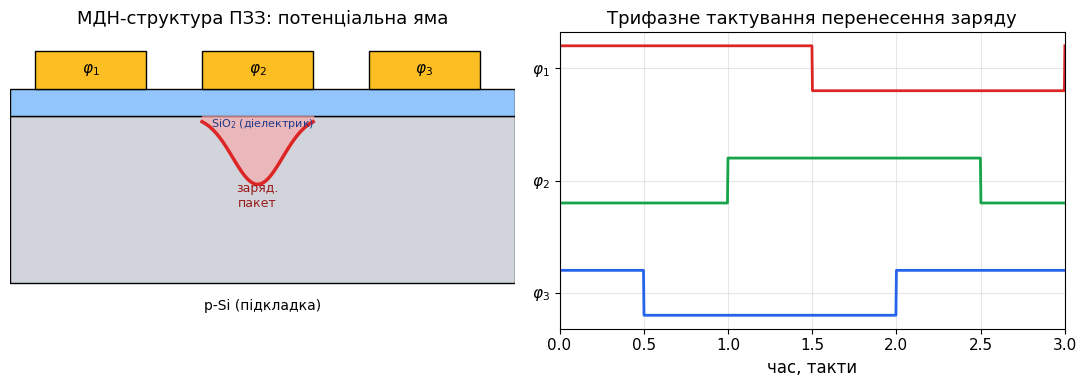

In [2]:
# Схема МДН-структури ПЗЗ та потенціальна яма під затвором
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# --- (a) Поперечний переріз МДН-структури ---
ax1.add_patch(mpatches.Rectangle((0, 0), 10, 2.2, facecolor='#d1d5db', edgecolor='k'))       # p-Si підкладка
ax1.add_patch(mpatches.Rectangle((0, 2.2), 10, 0.35, facecolor='#93c5fd', edgecolor='k'))    # SiO2
for i, x0 in enumerate([0.5, 3.8, 7.1]):
    ax1.add_patch(mpatches.Rectangle((x0, 2.55), 2.2, 0.5, facecolor='#fbbf24', edgecolor='k'))
    ax1.text(x0+1.1, 2.8, f'$\\varphi_{i+1}$', ha='center', va='center', fontsize=11)
# потенціальна яма під середнім електродом (глибша при вищій напрузі)
well_x = np.linspace(3.8, 6.0, 100)
well_y = 2.2 - 0.9*np.exp(-((well_x-4.9)/0.7)**2)
ax1.plot(well_x, well_y, color='#dc2626', lw=2.5)
ax1.fill_between(well_x, well_y, 2.2, color='#fca5a5', alpha=0.6)
ax1.text(4.9, 1.0, 'заряд.\nпакет', ha='center', color='#991b1b', fontsize=9)
ax1.text(5, -0.35, 'p-Si (підкладка)', ha='center', fontsize=10)
ax1.text(5, 2.05, 'SiO$_2$ (діелектрик)', ha='center', fontsize=8, color='#1e3a8a')
ax1.set_xlim(0, 10); ax1.set_ylim(-0.6, 3.3); ax1.axis('off')
ax1.set_title('МДН-структура ПЗЗ: потенціальна яма')

# --- (b) Часова діаграма трифазного тактування ---
t = np.linspace(0, 3, 1000)
def phase(t, shift):
    tt = (t - shift) % 3
    return np.where(tt < 1.5, 1.0, 0.2)
ax2.plot(t, phase(t, 0)+4, color='#dc2626', lw=2, label='$\\varphi_1$')
ax2.plot(t, phase(t, 1)+2, color='#16a34a', lw=2, label='$\\varphi_2$')
ax2.plot(t, phase(t, 2)+0, color='#2563eb', lw=2, label='$\\varphi_3$')
ax2.set_yticks([0.6, 2.6, 4.6]); ax2.set_yticklabels(['$\\varphi_3$', '$\\varphi_2$', '$\\varphi_1$'])
ax2.set_xlabel('час, такти')
ax2.set_title('Трифазне тактування перенесення заряду')
ax2.set_xlim(0, 3)
plt.tight_layout(); plt.show()

---
## Тиристорні прилади <a class="anchor" id="thyristor-family"></a>

**Тиристор** (у широкому сенсі) — це напівпровідниковий прилад на основі **чотиришарової структури p-n-p-n** із трьома p-n переходами, який має **два стійкі стани**: закритий (високий опір, струм через прилад практично відсутній) і відкритий (низький опір, прилад пропускає значний струм), а перехід між станами відбувається **лавиноподібно** (регенеративно) за рахунок внутрішнього позитивного зворотного зв'язку.

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати структуру та принцип дії диністора через двотранзисторну аналогію
> - Пояснювати роль керуючого електрода в тиристорі (тринисторі)
> - Будувати та інтерпретувати вольт-амперну характеристику тиристора
> - Пояснювати структуру та принцип дії симетричного тиристора (симістора)
> - Порівнювати способи вмикання та вимикання тиристорів і оцінювати перехідні процеси

</div>

### 📖 Ключові поняття

| Поняття | Пояснення |
|---------|-----------|
| **Анод (А), Катод (К)** | Силові виводи чотиришарової структури (крайні p- та n-області) |
| **Керуючий електрод (КЕ, G)** | Додатковий вивід від внутрішньої базової області для вмикання приладу |
| **Напруга перемикання $U_{пер}$ (breakover, $V_{BO}$)** | Напруга, за якої тиристор без керуючого сигналу самостійно переходить у відкритий стан |
| **Струм утримання $I_{утр}$ (holding current)** | Мінімальний анодний струм, за якого регенеративний зв'язок ще підтримується у відкритому стані |
| **Регенеративний (лавинний) зворотний зв'язок** | Механізм самопідтримки відкритого стану за рахунок взаємного підсилення двох транзисторних структур |

## Диністор <a class="anchor" id="dinistor"></a>

**Диністор** (некерований, або двоелектродний тиристор) — це прилад із чотиришаровою структурою p₁-n₁-p₂-n₂ і **двома** зовнішніми виводами: анодом (до крайньої області p₁) і катодом (до крайньої області n₂). Два крайні p-n переходи (П1 та П3) називають **емітерними**, середній перехід (П2) — **колекторним**.

### Двотранзисторна аналогія

Найнаочніше принцип дії диністора пояснює його представлення у вигляді **двох взаємопов'язаних біполярних транзисторів**: структуру p₁-n₁-p₂ можна розглядати як транзистор $VT_1$ типу p-n-p, а структуру n₁-p₂-n₂ — як транзистор $VT_2$ типу n-p-n, причому колектор $VT_1$ з'єднаний з базою $VT_2$, а колектор $VT_2$ — з базою $VT_1$ (перехресний зв'язок, тобто вихід кожного транзистора є входом іншого).

Якщо прикласти до диністора пряму напругу (плюс на аноді), емітерні переходи П1 і П3 зміщені прямо, а середній перехід П2 — зворотно; майже вся прикладена напруга падає саме на П2, і струм через прилад малий (визначається зворотним струмом колекторного переходу $I_{К0}$). Проте зі збільшенням напруги зростає струм через П2, а разом з ним — і коефіцієнти передачі струму емітера $\alpha_1$ (для $VT_1$) та $\alpha_2$ (для $VT_2$), оскільки при малих струмах $\alpha$ зростає зі струмом емітера. Струм колекторного переходу можна записати як

$$I_К = \alpha_1 I + \alpha_2 I + I_{К0} = (\alpha_1+\alpha_2) I + I_{К0},$$

де $I$ — загальний струм через прилад (він же струм обох емітерів). Якщо покласти $I=I_К$ (послідовне з'єднання шарів), отримуємо

$$I = \frac{I_{К0}}{1-(\alpha_1+\alpha_2)}.$$

Поки сума $\alpha_1+\alpha_2 < 1$, вираз описує стійкий стан із малим струмом. Але як тільки, унаслідок зростання напруги (а отже й струму), виконується умова

$$\alpha_1+\alpha_2 \to 1,$$

знаменник прямує до нуля, і струм лавиноподібно наростає — це і є **регенеративний процес перемикання**: збільшення струму підвищує $\alpha_1$ і $\alpha_2$, що ще більше збільшує струм, і так до тих пір, поки процес не обмежиться зовнішнім опором кола. Диністор переходить у відкритий стан, у якому всі три переходи зміщені в напрямку, що підтримує протікання великого струму, а спадання напруги на приладі мале (близько 1 В).

## Тиристор з керуючим електродом (тринистор) <a class="anchor" id="scr-thyristor"></a>

**Тринистор** (частіше просто **тиристор**, англ. *SCR — Silicon Controlled Rectifier*) відрізняється від диністора наявністю **третього виводу** — керуючого електрода (КЕ), приєднаного до однієї з внутрішніх базових областей (найчастіше — до p-області поруч із катодом).

Подача позитивного струму керування $I_у$ у базу транзистора $VT_2$ еквівалентна додатковій інжекції носіїв, яка **штучно збільшує** добуток $\alpha_1+\alpha_2$ до одиниці **за значно нижчої анодної напруги**, ніж напруга природного перемикання $U_{пер}$ диністора. Що більший струм керування — то за меншої анодної напруги вмикається прилад; за досить великого $I_у$ тиристор вмикається практично при будь-якій позитивній напрузі на аноді (аналогічно диністору). Після вмикання роль керуючого електрода вичерпується: подальше протікання струму підтримується самим регенеративним зв'язком, і зняття сигналу керування **не вимикає** тиристор (вимкнути можна лише зниженням анодного струму нижче струму утримання $I_{утр}$ або зміною полярності напруги).

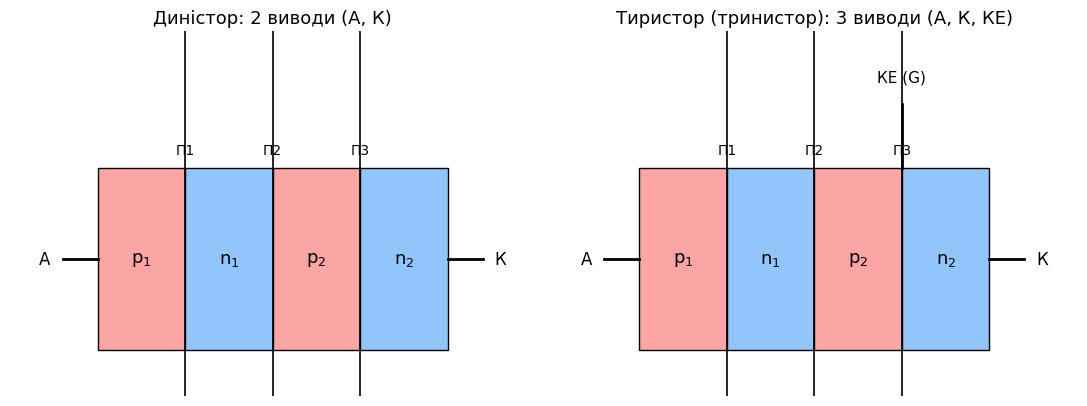

In [3]:
# Структурні схеми диністора та тиристора (4-шарова p-n-p-n структура)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

layers = [('p$_1$', '#fca5a5'), ('n$_1$', '#93c5fd'), ('p$_2$', '#fca5a5'), ('n$_2$', '#93c5fd')]

def draw_pnpn(ax, with_gate):
    for i, (lbl, color) in enumerate(layers):
        ax.add_patch(mpatches.Rectangle((i*1.5, 0), 1.5, 2, facecolor=color, edgecolor='k'))
        ax.text(i*1.5+0.75, 1, lbl, ha='center', va='center', fontsize=13)
    for i in range(1, 4):
        ax.axvline(i*1.5, color='k', lw=1.2, ymin=0, ymax=1)
        ax.text(i*1.5, 2.15, f'П{i}', ha='center', fontsize=10)
    ax.plot([-0.6, 0], [1, 1], 'k-', lw=2)
    ax.text(-0.9, 1, 'А', ha='center', va='center', fontsize=12)
    ax.plot([6, 6.6], [1, 1], 'k-', lw=2)
    ax.text(6.9, 1, 'К', ha='center', va='center', fontsize=12)
    if with_gate:
        ax.plot([4.5, 4.5], [2, 2.7], 'k-', lw=2)
        ax.text(4.5, 3.0, 'КЕ (G)', ha='center', va='center', fontsize=11)
    ax.set_xlim(-1.5, 7.5); ax.set_ylim(-0.5, 3.5); ax.axis('off')

draw_pnpn(axes[0], with_gate=False)
axes[0].set_title('Диністор: 2 виводи (А, К)')
draw_pnpn(axes[1], with_gate=True)
axes[1].set_title('Тиристор (тринистор): 3 виводи (А, К, КЕ)')
plt.tight_layout(); plt.show()

## Вольт-амперна характеристика тиристора <a class="anchor" id="thyristor-vi-curve"></a>

ВАХ тиристора (і диністора як окремого випадку при $I_у=0$) має характерну **S-подібну** форму з ділянкою від'ємного диференціального опору:

- **Ділянка закритого стану (0–1):** струм малий (одиниці мА і менше), опір великий, напруга зростає майже пропорційно до прикладеної (з невеликим нахилом за рахунок росту $\alpha_1+\alpha_2$).
- **Точка перемикання (1):** при $U=U_{пер}$ (без КЕ) або раніше — за наявності струму керування $I_у>0$ — виконується умова $\alpha_1+\alpha_2=1$, і подальше зростання струму відбувається за спадної напруги.
- **Ділянка від'ємного опору (1–2):** нестійка ділянка, на практиці не спостерігається як стійкий робочий стан (робоча точка "перестрибує" по навантажувальній прямій).
- **Ділянка відкритого стану (2–3):** прилад поводиться майже як звичайний прямозміщений діод — малий спад напруги (~1 В) за великих струмів; струм обмежується лише зовнішнім навантаженням.
- **Струм утримання $I_{утр}$ (точка 2):** якщо струм у відкритому стані зменшити нижче $I_{утр}$, регенеративний зв'язок зривається, і прилад повертається у закритий стан.
- **Зворотна гілка:** при зворотній напрузі (мінус на аноді) крайні переходи П1, П3 зміщені зворотно — тиристор поводиться як звичайний закритий діод, аж до **зворотного пробою** при $U_{зв.max}$.

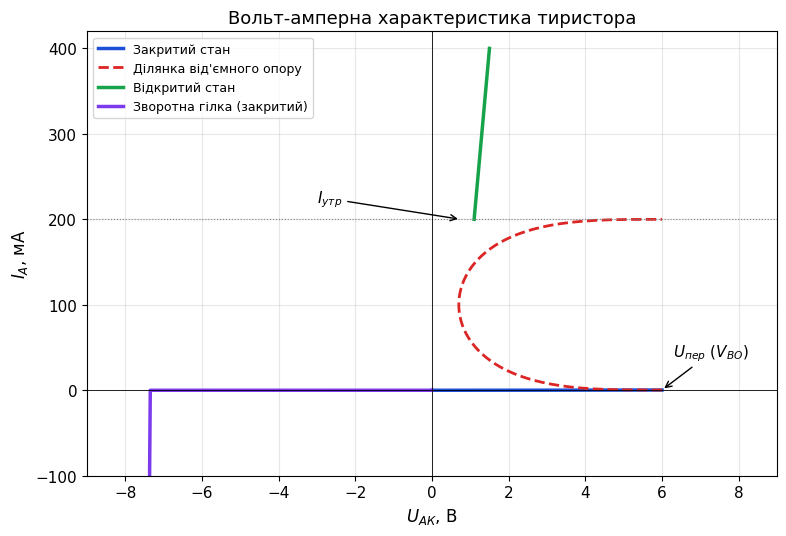

In [4]:
# Аналітична побудова ВАХ тиристора (S-подібна крива з ділянкою від'ємного опору)
fig, ax = plt.subplots(figsize=(8, 5.5))

# Закритий стан (0..Uper)
U_off = np.linspace(0, 6, 50)
I_off = 0.02 * U_off**1.5

# Ділянка перемикання (від'ємний опір), параметрично
theta = np.linspace(0, np.pi, 60)
U_switch = 6 - 5.3*np.sin(theta)**0.6
I_switch = 0.02*6**1.5 + (200 - 0.02*6**1.5) * (1-np.cos(theta))/2

# Відкритий стан
I_on = np.linspace(I_switch[-1], 400, 40)
U_on = 0.7 + 0.002*I_on

# Зворотна гілка
U_rev = np.linspace(0, -8, 50)
I_rev = np.where(U_rev > -7.5, -0.001*np.abs(U_rev)**1.2, -0.001*7.5**1.2 - 60*(np.abs(U_rev)+7.5))

ax.plot(U_off, I_off, color='#1d4ed8', lw=2.5, label='Закритий стан')
ax.plot(U_switch, I_switch, color='#dc2626', lw=2, ls='--', label="Ділянка від'ємного опору")
ax.plot(U_on, I_on, color='#16a34a', lw=2.5, label='Відкритий стан')
ax.plot(U_rev, I_rev, color='#7c3aed', lw=2.5, label='Зворотна гілка (закритий)')

ax.axhline(I_switch[-1], color='gray', lw=0.8, ls=':')
ax.annotate('$U_{пер}$ ($V_{BO}$)', xy=(6, 0.02*6**1.5), xytext=(6.3, 40),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('$I_{утр}$', xy=(0.75, I_switch[-1]), xytext=(-3, I_switch[-1]+20),
            arrowprops=dict(arrowstyle='->'))
ax.axvline(0, color='k', lw=0.6); ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('$U_{АК}$, В'); ax.set_ylabel('$I_{А}$, мА')
ax.set_title('Вольт-амперна характеристика тиристора')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-9, 9); ax.set_ylim(-100, 420)
plt.tight_layout(); plt.show()

## Симетричні тиристори (симістори, TRIAC) <a class="anchor" id="triac"></a>

**Симістор** (симетричний тиристор, англ. *TRIAC — TRIode for Alternating Current*) — це прилад, здатний проводити струм **в обох напрямках**, що еквівалентно **двом зустрічно-паралельно** увімкненим тиристорам, виготовленим на одному кристалі. Симістор має п'ятишарову структуру та три виводи: два силові (умовно позначаються $A_1/T_1$ та $A_2/T_2$, а не "анод/катод", бо кожен з них по черзі відіграє роль анода) і керуючий електрод.

Оскільки симістор симетричний, керування можливе в **чотирьох квадрантах** (комбінаціях полярності напруги $A_2$–$A_1$ та полярності струму керування):

| Квадрант | Полярність $U_{A2A1}$ | Полярність $I_у$ | Чутливість |
|---|---|---|---|
| I+ | + | + | найвища |
| I− | + | − | висока |
| III+ | − | + | низька (не рекомендується) |
| III− | − | − | висока |

ВАХ симістора — це **дзеркально-симетрична** відносно початку координат ВАХ звичайного тиристора: у першому квадранті вона повністю повторює розглянуту вище S-подібну криву, у третьому — її дзеркальне відображення. Симістори широко застосовують для регулювання потужності в колах **змінного струму** — регулятори яскравості освітлення (диммери), регулятори швидкості обертання двигунів, безконтактні пускачі — саме тому, що не потребують окремого випрямляча чи двох тиристорів для обох півхвиль напруги.

## Способи вмикання та вимикання тиристорів <a class="anchor" id="thyristor-switching"></a>

### Способи вмикання (переведення в відкритий стан)

1. **Керуючим імпульсом струму** ($I_у$) — основний, штатний спосіб; амплітуда й тривалість імпульсу мають перевищувати паспортні значення струму та часу вмикання.
2. **Перевищенням напруги** ($U > U_{пер}$, лавинне/динисторне вмикання) — небажаний режим для керованих тиристорів (відбувається без сигналу керування, некероване вмикання), проте це основний робочий механізм для диністорів.
3. **Швидким наростанням напруги** ($du/dt$) — через ємність колекторного переходу П2 виникає ємнісний струм зміщення $i_c = C\,du/dt$, який відіграє роль керуючого струму; перевищення паспортного значення $(du/dt)_{max}$ призводить до небажаного самовільного вмикання.
4. **Дією світла** (фототиристори) — генерація електронно-діркових пар світлом в області керуючого переходу еквівалентна подачі струму керування.
5. **Нагрівом** — зростання температури збільшує $I_{К0}$ і коефіцієнти $\alpha$, що також може спричинити небажане самовільне вмикання при перегріві.

### Способи вимикання

Оскільки регенеративний зв'язок **не переривається** зняттям сигналу керування, вимкнути тиристор можна лише розірвавши сам зворотний зв'язок — тобто знизивши анодний струм нижче струму утримання $I_{утр}$:

1. **Природна комутація (лінійна, мережева)** — у колах змінного струму прилад сам вимикається щопівперіоду, коли струм переходить через нуль при зміні полярності напруги мережі (найпростіший спосіб, притаманний AC-застосуванням).
2. **Примусова (штучна) комутація** — у колах постійного струму застосовують допоміжні LC-кола, які на короткий час пропускають через тиристор зустрічний струм, що компенсує прямий струм до нуля й нижче струму утримання.

### Перехідні процеси вмикання і вимикання

При **вмиканні** струм наростає не миттєво: спочатку існує **час затримки** $t_d$ (поки регенеративний процес не розів'ється), потім **час наростання** $t_r$ струму до робочого значення; область провідного каналу при цьому поширюється від зони поруч із керуючим електродом на весь переріз структури з кінцевою швидкістю (десятки мкм/мкс), тому швидкість наростання анодного струму $di/dt$ обмежують ззовні (послідовним дроселем), інакше виникає локальний перегрів і пробій ("шнурування" струму).

При **вимиканні** (після зниження струму до нуля чи нижче) прилад ще певний час **не здатний блокувати пряму напругу** — це так званий **час вимикання** $t_q$ (turn-off time), необхідний для розсмоктування надлишкового заряду неосновних носіїв у базових областях. Якщо пряму напругу прикласти раніше, ніж мине $t_q$, тиристор небажано ввімкнеться знову (це явище обмежує максимальну робочу частоту тиристорних схем).

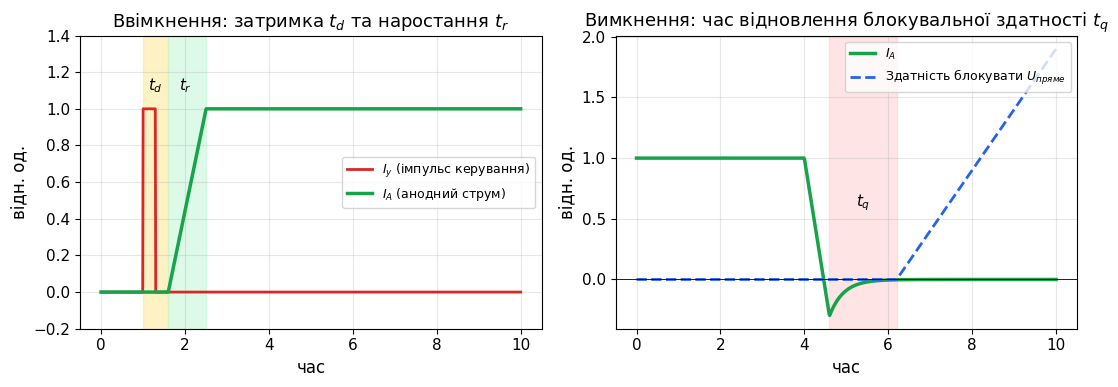

In [5]:
# Ідеалізовані діаграми перехідних процесів вмикання/вимикання тиристора
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

t = np.linspace(0, 10, 1000)
Ig = np.where((t > 1) & (t < 1.3), 1.0, 0.0)
Ia = np.zeros_like(t)
mask_delay = (t >= 1) & (t < 1.6)
mask_rise = (t >= 1.6) & (t < 2.5)
mask_on = (t >= 2.5)
Ia[mask_rise] = (t[mask_rise]-1.6)/0.9
Ia[mask_on] = 1.0
ax1.plot(t, Ig, color='#dc2626', label='$I_у$ (імпульс керування)')
ax1.plot(t, Ia, color='#16a34a', lw=2.5, label='$I_А$ (анодний струм)')
ax1.axvspan(1.0, 1.6, color='#fde68a', alpha=0.5)
ax1.axvspan(1.6, 2.5, color='#bbf7d0', alpha=0.5)
ax1.text(1.3, 1.1, '$t_d$', ha='center')
ax1.text(2.0, 1.1, '$t_r$', ha='center')
ax1.set_xlabel('час'); ax1.set_ylabel('відн. од.')
ax1.set_title('Ввімкнення: затримка $t_d$ та наростання $t_r$')
ax1.legend(loc='center right', fontsize=9); ax1.set_ylim(-0.2, 1.4)

t2 = np.linspace(0, 10, 1000)
Ia2 = np.where(t2 < 4, 1.0, np.where(t2 < 4.6, 1 - (t2-4)/0.6*1.3, -0.3*np.exp(-(t2-4.6)*3)))
Ublock = np.where(t2 < 6.2, 0.0, (t2-6.2)/2*1.0)
ax2.plot(t2, Ia2, color='#16a34a', lw=2.5, label='$I_А$')
ax2.plot(t2, Ublock, color='#2563eb', lw=2, ls='--', label='Здатність блокувати $U_{пряме}$')
ax2.axvspan(4.6, 6.2, color='#fecaca', alpha=0.5)
ax2.text(5.4, 0.6, '$t_q$', ha='center')
ax2.axhline(0, color='k', lw=0.6)
ax2.set_xlabel('час'); ax2.set_ylabel('відн. од.')
ax2.set_title('Вимкнення: час відновлення блокувальної здатності $t_q$')
ax2.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Ідею чотиришарової p-n-p-n структури як перемикального приладу запропонував ще **Вільям Шоклі** у середині 1950-х (т. зв. "диністор Шоклі", 1956), а перший практичний керований тиристор (SCR) комерціалізувала компанія **General Electric** у 1957 р. — розробку очолював інженер Гордон Голл (Gordon Hall) за участю групи під керівництвом Джона Мола. Поява тиристорів фактично поклала початок сучасній **силовій електроніці**: до того потужні керовані випрямлячі й регулятори будували на газорозрядних приладах (тиратронах, ігнітронах), значно менш надійних і довговічних.

</div>

### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Студенти часто плутають три прилади цієї родини за кількістю виводів і способом вмикання. **Диністор** — 2 виводи, вмикається лише перевищенням напруги (некерований). **Тиристор (тринистор)** — 3 виводи, вмикається імпульсом струму керування, провідний лише в одному напрямку. **Симістор** — 3 виводи (два силові + керуючий), провідний в **обох** напрямках, еквівалентний двом зустрічним тиристорам. Не можна казати "симістор — це тиристор із двома керуючими електродами": керуючий електрод у симістора один, а двонапрямленість забезпечує саме п'ятишарова симетрична структура кристала.

</div>

### ⚡ Практичне застосування: Фазове регулювання потужності

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Найпоширеніше застосування тиристорів і симісторів — **фазове регулювання** діючої потужності в навантаженні змінного струму: подаючи керуючий імпульс із затримкою $\theta$ відносно переходу мережевої напруги через нуль, регулюють, яку частину кожного півперіоду прилад проводить струм. На цьому принципі побудовані побутові регулятори яскравості освітлення (диммери), регулятори потужності нагрівачів, безконтактні пускачі та пристрої **м'якого пуску** асинхронних двигунів (soft starters), що обмежують пусковий струм двигуна, поступово збільшуючи кут провідності від нуля до максимуму.

</div>

### ✅ Питання для самоперевірки: ПЗЗ та тиристорні прилади

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому в ПЗЗ використовують саме послідовність тактових імпульсів на групах електродів, а не постійну напругу?</summary>

> **Відповідь:** Постійна напруга лише утворює й утримує потенціальну яму в одному місці. Щоб зчитати заряд, його потрібно перемістити до вихідного каскаду; це досягається створенням поруч глибшої ями (вищою напругою на сусідньому електроді) і послідовним, синхронізованим у часі "перемиканням" глибини ям — тобто саме циклічним тактуванням.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому диністор не можна вимкнути, просто "прибравши" причину його вмикання (наприклад, зменшивши напругу до значення нижче $U_{пер}$)?</summary>

> **Відповідь:** Після вмикання регенеративний зв'язок підтримує себе сам, поки анодний струм не опуститься нижче струму утримання $I_{утр}$. Зниження напруги на приладі саме по собі не гарантує зниження струму нижче $I_{утр}$, якщо зовнішнє коло (навантаження) продовжує забезпечувати достатній струм — вимкнення настає лише тоді, коли струм, а не напруга, падає нижче порогового значення.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому обмежують швидкість наростання анодного струму $di/dt$ при вмиканні тиристора?</summary>

> **Відповідь:** Провідна область поширюється від зони поблизу керуючого електрода на весь переріз кристала з кінцевою швидкістю. Якщо струм наростає швидше, ніж встигає розширитися провідна область, уся густина струму концентрується у вузькій зоні ("шнурування струму"), що спричиняє локальний перегрів і може призвести до незворотного пошкодження кристала.

</details>

---

## IGBT-транзистори <a class="anchor" id="igbt"></a>

**IGBT** (англ. *Insulated Gate Bipolar Transistor* — біполярний транзистор з ізольованим затвором) — це гібридний силовий прилад, який поєднує в одній структурі **МОН-транзистор** на вході (керування затвором) і **біполярний транзистор** на виході (низька напруга насичення при великих струмах), об'єднуючи переваги обох.

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати структуру IGBT та його еквівалентну схему заміщення
> - Пояснювати, чому IGBT керується напругою (як МОН-транзистор), але має малий спад напруги (як біполярний)
> - Наводити основні статичні характеристики IGBT
> - Порівнювати переваги й недоліки IGBT відносно потужного МОН-транзистора та біполярного транзистора
> - Наводити типові області застосування IGBT

</div>

### Конструкція та еквівалентна схема

Структура IGBT — це, по суті, **МОН-транзистор із індукованим n-каналом**, у якого замість звичайного n⁺-стоку додано ще один p⁺-шар (колекторна область), утворюючи додатковий p-n перехід. Струм, що протікає через МОН-канал, одночасно є базовим струмом для паразитного (а точніше — навмисно використовуваного) **вертикального p-n-p транзистора**, утвореного шарами p⁺(колектор)–n⁻(дрейфова область)–p(область каналу). Таким чином, IGBT еквівалентний схемі з **МОН-транзистора, що керує базою біполярного p-n-p транзистора** (Дарлінгтон-подібне з'єднання МОН + БТ):

- **Затвор (G)** — ізольований, як у звичайного МОН-транзистора; керування — напругою, вхідний струм затвора практично нульовий у сталому режимі (лише перезаряд ємності при перемиканні).
- **Колектор (C)** і **емітер (E)** — силові виводи, названі за аналогією з біполярним транзистором, оскільки вихідна частина структури — біполярна.
- Додатково в структурі часто присутній паразитний **тиристор** (n⁺-p-n⁻-p⁺), і конструктивно вживають заходів (шунтування бази n-p-n шаром із підвищеною провідністю), щоб запобігти його небажаному відмиканню — явищу **"защіпання" (latch-up)**, яке обмежує максимальний робочий струм IGBT.

### Статичні та перемикальні характеристики

Вихідні (колекторні) характеристики $I_C(U_{CE})$ при різних напругах затвор-емітер $U_{GE}$ якісно нагадують характеристики біполярного транзистора: є область насичення з малим нахилом і малим залишковим спадом напруги $U_{CE(sat)}$ (типово 1,5–3,5 В — менше, ніж у потужного МОН-транзистора з порівнянним номінальним струмом, у якого спад визначається опором каналу $R_{DS(on)}$ і зростає зі струмом майже лінійно). Передавальна характеристика $I_C(U_{GE})$ подібна до характеристики МОН-транзистора: струм з'являється лише після порогової напруги $U_{GE(th)}$ і далі зростає приблизно квадратично/лінійно залежно від режиму.

**Перемикання.** При вимиканні IGBT (закритті МОН-каналу) вертикальний біполярний транзистор ще деякий час продовжує проводити накопичений у широкій слаболегованій n⁻-базі надлишковий заряд неосновних носіїв, що проявляється як так званий **"хвіст" струму** (*tail current*) на осцилограмі вимикання — струм спадає не миттєво, а спочатку швидко (заряд каналу МОН), потім значно повільніше (рекомбінація заряду в базі біполярної частини). Це головна причина того, що IGBT перемикається **повільніше**, ніж потужний МОН-транзистор порівнянної напруги, і має більші динамічні втрати на високих частотах.

### Переваги та недоліки

| Переваги IGBT | Недоліки IGBT |
|---|---|
| Керування напругою, дуже малий вхідний струм (як у МОН) | Повільніше перемикання, ніж у потужного МОН (через "хвіст" струму) |
| Малий спад напруги при великих струмах (як у біполярного) | Більші динамічні втрати на високих частотах перемикання |
| Високі робочі напруги й струми (сотні–тисячі В, сотні А) | Ризик защіпання (latch-up) при перевищенні граничного струму |
| Простий та дешевий драйвер затвора | Дещо гірші характеристики при низьких температурах порівняно з МОН |

**Області застосування:** перетворювачі частоти та привóди електродвигунів середньої й великої потужності, інвертори (у тому числі сонячних електростанцій та ІБЖ), зварювальні апарати інверторного типу, тягова електроніка (електротранспорт, локомотиви) — усюди, де потрібні високі напруги/струми при відносно помірних (одиниці–десятки кГц) частотах перемикання, на відміну від високочастотних імпульсних перетворювачів малої потужності, де перевагу віддають потужним МОН-транзисторам.

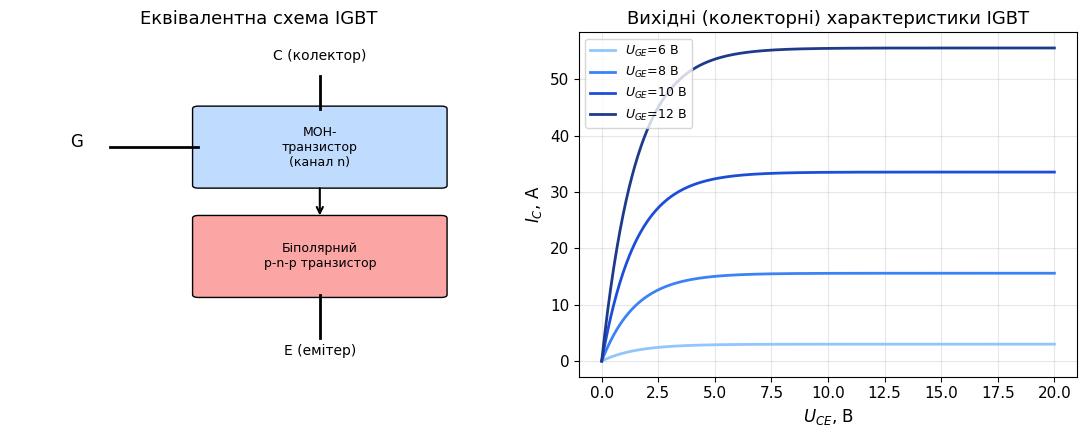

In [6]:
# Спрощена еквівалентна схема IGBT та якісні вихідні характеристики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# --- (a) Еквівалентна схема: МОН керує базою p-n-p ---
ax1.add_patch(mpatches.FancyBboxPatch((0.2, 2.2), 2.2, 1.4, boxstyle="round,pad=0.05",
                                      facecolor='#bfdbfe', edgecolor='k'))
ax1.text(1.3, 2.9, 'МОН-\nтранзистор\n(канал n)', ha='center', va='center', fontsize=9)
ax1.add_patch(mpatches.FancyBboxPatch((0.2, 0.2), 2.2, 1.4, boxstyle="round,pad=0.05",
                                      facecolor='#fca5a5', edgecolor='k'))
ax1.text(1.3, 0.9, 'Біполярний\np-n-p транзистор', ha='center', va='center', fontsize=9)
ax1.annotate('', xy=(1.3, 1.6), xytext=(1.3, 2.2), arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.plot([-0.6, 0.2], [2.9, 2.9], 'k-', lw=2); ax1.text(-0.9, 2.9, 'G', ha='center', fontsize=12)
ax1.plot([1.3, 1.3], [3.6, 4.2], 'k-', lw=2); ax1.text(1.3, 4.5, 'C (колектор)', ha='center', fontsize=10)
ax1.plot([1.3, 1.3], [-0.6, 0.2], 'k-', lw=2); ax1.text(1.3, -0.9, 'E (емітер)', ha='center', fontsize=10)
ax1.set_xlim(-1.5, 3); ax1.set_ylim(-1.3, 5); ax1.axis('off')
ax1.set_title('Еквівалентна схема IGBT')

# --- (b) Вихідні характеристики I_C(U_CE) при різних U_GE ---
Uce = np.linspace(0, 20, 300)
for Uge, color in zip([6, 8, 10, 12], ['#93c5fd', '#3b82f6', '#1d4ed8', '#1e3a8a']):
    k = (Uge-5)**1.5 * 3
    Ic = k * (1 - np.exp(-Uce/1.5))
    ax2.plot(Uce, Ic, color=color, label=f'$U_{{GE}}$={Uge} В')
ax2.set_xlabel('$U_{CE}$, В'); ax2.set_ylabel('$I_C$, А')
ax2.set_title('Вихідні (колекторні) характеристики IGBT')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

### ✅ Питання для самоперевірки: IGBT

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому вхідний керуючий струм IGBT в сталому режимі майже нульовий, хоча вихідна частина структури — біполярна?</summary>

> **Відповідь:** Керування відбувається через ізольований (МОН) затвор, який утворює провідний канал електричним полем, а не інжекцією струму. Біполярна частина структури керується не струмом бази ззовні, а струмом самого МОН-каналу — тобто "струм бази" для внутрішнього p-n-p транзистора формується всередині кристала, а не подається через зовнішній вивід.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чим пояснюється "хвіст" струму (tail current) при вимиканні IGBT і до чого він призводить?</summary>

> **Відповідь:** Після закриття МОН-каналу в широкій слаболегованій n⁻-базі біполярної частини залишається накопичений заряд неосновних носіїв, який не може зникнути миттєво — лише рекомбінувати за кінцевий час. Це проявляється як повільно спадаючий "хвіст" колекторного струму й спричиняє додаткові динамічні втрати потужності, що обмежує максимальну робочу частоту IGBT порівняно з потужними МОН-транзисторами.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому для приводів електродвигунів середньої й великої потужності частіше обирають IGBT, а не потужні МОН-транзистори?</summary>

> **Відповідь:** При великих робочих напругах і струмах вирішальним є малий залишковий спад напруги (а отже, і статичні втрати) IGBT, тоді як робочі частоти таких приводів відносно невисокі (одиниці–десятки кГц), тому підвищені динамічні втрати IGBT некритичні. У МОН-транзисторів порівнянної напруги опір каналу $R_{DS(on)}$ зростає настільки, що статичні втрати на великих струмах стають надмірними.

</details>

---

## Оптоелектронні прилади <a class="anchor" id="optoelectronics"></a>

**Оптоелектронні прилади** перетворюють оптичне випромінювання в електричний сигнал (фоторезистори, фотодіоди) або навпаки — електричний сигнал в оптичне випромінювання (світлодіоди, розглянуті нижче), а також поєднують обидва перетворення в одному корпусі для гальванічної розв'язки кіл (оптрони).

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати принцип дії фоторезистора та його основні характеристики
> - Пояснювати принцип дії фотодіода у фотогальванічному та фотодіодному режимах, наводити різновиди фотодіодів
> - Пояснювати призначення та типи оптронів

</div>

## Фоторезистори <a class="anchor" id="photoresistor"></a>

**Фоторезистор** (англ. *LDR — Light Dependent Resistor*) — найпростіший фотоелектричний прилад, опір якого змінюється під дією світлового потоку за рахунок явища **фотопровідності**: поглинутий фотон із енергією $h\nu \ge E_g$ (або енергією, достатньою для переходу з домішкового рівня) генерує додаткову пару вільних носіїв заряду (електрон-дірку), що збільшує концентрацію носіїв і, відповідно, електропровідність напівпровідникового матеріалу (найчастіше — тонкої меандрової плівки CdS або CdSe, нанесеної на діелектричну підкладку з двома металевими гребінчастими електродами).

Опір фоторезистора зменшується зі зростанням освітленості $E$ приблизно за степеневим законом:

$$R(E) = R_{тем} \cdot \left(\frac{E_0}{E}\right)^{\gamma}, \qquad 0{,}5 \lesssim \gamma \lesssim 1,$$

де $R_{тем}$ — темновий опір (опір без засвітлення, зазвичай $10^5$–$10^7$ Ом), а показник $\gamma$ залежить від матеріалу й технології. Через відсутність p-n переходу фоторезистор — значно **інерційніший (повільніший)**, ніж фотодіод (стала часу — одиниці–десятки мс, а не наносекунди), проте істотно **дешевший і простіший**; застосовується в автоматиці освітлення, фотоекспонометрах, датчиках сутінків.

## Фотодіоди <a class="anchor" id="photodiode"></a>

**Фотодіод** — це напівпровідниковий діод, у якому робочою є область **p-n переходу**, освітлювана через прозоре вікно корпусу. Поглинання світла в збідненій області (та поблизу неї) генерує електронно-діркові пари, які під дією поля переходу розділяються: неосновні носії (для кожної з областей) підхоплюються полем і створюють **фотострум**, напрямлений так само, як і зворотний (тепловий) струм переходу.

### Режими роботи

- **Фотогальванічний (вентильний) режим** — без зовнішньої напруги живлення ($U=0$): p-n перехід сам стає джерелом ЕРС (принцип роботи сонячного елемента); придатний для вимірювання малих потоків без джерела живлення, але повільніший і менш лінійний.
- **Фотодіодний (фотоперетворювальний) режим** — з прикладеною **зворотною** напругою зміщення: розширюється область збіднення (менша ємність переходу → вища швидкодія), а фотострум практично лінійно пропорційний до світлового потоку в широкому діапазоні освітленостей; це основний робочий режим для вимірювальних і швидкодіючих застосувань.

Сімейство ВАХ фотодіода при різних рівнях освітленості описується модифікованим рівнянням діода з доданим фотострумом $I_{ф}$, напрямленим у зворотному напрямку:

$$I = I_0\left(e^{U/(nV_T)}-1\right) - I_ф(E),$$

де $I_ф(E)$ монотонно зростає з освітленістю $E$. За нульової напруги ($U=0$) струм дорівнює $-I_ф$ — це і є короткозамкнений фотострум; за розімкненого кола ($I=0$) на переході встановлюється фотоЕРС.

### Різновиди фотодіодів

| Тип | Особливість | Застосування |
|---|---|---|
| **p-n фотодіод** | Класична структура | Загального призначення |
| **PIN-фотодіод** | Широка власна (i) область між p та n → більша об'ємна область поглинання, менша ємність, вища швидкодія | Волоконно-оптичний зв'язок, високошвидкісні датчики |
| **Лавинний фотодіод (ЛФД, APD)** | Робота при зворотній напрузі, близькій до лавинного пробою → внутрішнє підсилення фотоструму (лавинне множення) | Слабкі оптичні сигнали, LIDAR, квантова оптика |
| **Фотодіод Шотки** | Контакт метал-напівпровідник замість p-n переходу | УФ- та короткохвильова чутливість, дуже висока швидкодія |

Спектральна чутливість фотодіода обмежена знизу енергією фотона, достатньою для міжзонного переходу ($\lambda_{max} \approx 1240/E_g$ нм), а зверху — глибиною проникнення світла (для дуже коротких хвиль поглинання відбувається занадто близько до поверхні, де більше рекомбінаційних втрат).

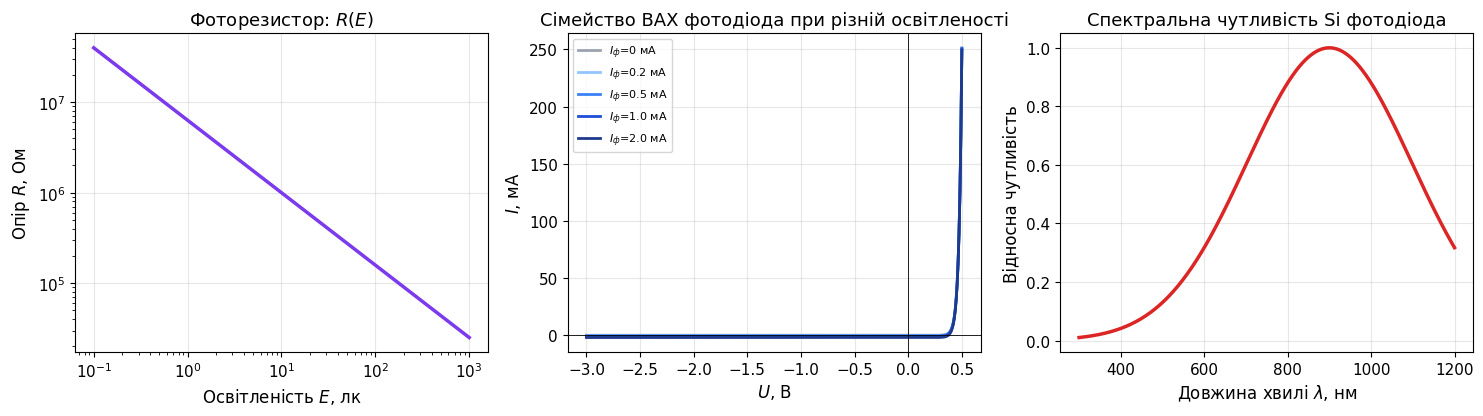

In [7]:
# (a) Опір фоторезистора vs освітленість (лог-лог); (b) сімейство ВАХ фотодіода; (c) спектральна чутливість
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

E = np.logspace(-1, 3, 200)   # лк
R = 1e6 * (10/E)**0.8
axes[0].loglog(E, R, color='#7c3aed', lw=2.5)
axes[0].set_xlabel('Освітленість $E$, лк'); axes[0].set_ylabel('Опір $R$, Ом')
axes[0].set_title('Фоторезистор: $R(E)$')

Vt = 0.02585
I0 = 1e-9
U = np.linspace(-3, 0.5, 400)
for Iph_mA, color in zip([0, 0.2, 0.5, 1.0, 2.0], ['#9ca3af', '#93c5fd', '#3b82f6', '#1d4ed8', '#1e3a8a']):
    I = I0*(np.exp(U/Vt)-1) - Iph_mA*1e-3
    axes[1].plot(U, I*1e3, color=color, label=f'$I_ф$={Iph_mA} мА')
axes[1].axhline(0, color='k', lw=0.6); axes[1].axvline(0, color='k', lw=0.6)
axes[1].set_xlabel('$U$, В'); axes[1].set_ylabel('$I$, мА')
axes[1].set_title('Сімейство ВАХ фотодіода при різній освітленості')
axes[1].legend(fontsize=8)

lam = np.linspace(300, 1200, 400)
S = np.exp(-((lam-900)/280)**2)
axes[2].plot(lam, S, color='#dc2626', lw=2.5)
axes[2].set_xlabel('Довжина хвилі $\\lambda$, нм'); axes[2].set_ylabel('Відносна чутливість')
axes[2].set_title('Спектральна чутливість Si фотодіода')
plt.tight_layout(); plt.show()

## Оптрони <a class="anchor" id="optocoupler"></a>

**Оптрон (оптопара)** — це прилад, що поєднує в одному корпусі **випромінювач світла** (найчастіше — інфрачервоний світлодіод) та **фотоприймач**, оптично зв'язані між собою, але **гальванічно (електрично) повністю розв'язані**: сигнал передається через прозорий діелектричний проміжок у вигляді світлового потоку, а не електричного струму. Це дозволяє передавати сигнал між колами з різними (у тому числі дуже різними, до кількох кіловольт) потенціалами без електричного з'єднання.

### Основні типи оптронів

| Тип | Фотоприймач | Особливості | Застосування |
|---|---|---|---|
| **Транзисторний** | Фототранзистор | Помірна швидкодія, підсилення струму фотоприймачем | Гальванічна розв'язка цифрових сигналів, логічних рівнів |
| **Діодний** | Фотодіод (+ підсилювач) | Висока швидкодія | Швидкісна передача даних, інтерфейси |
| **Тиристорний / симісторний** | Фототиристор / фотосимістор | Комутація силових кіл змінного струму | Твердотільні реле (SSR), керування навантаженням мережі |
| **Резисторний (оптрон з фоторезистором)** | Фоторезистор (наприклад, на основі CdS) | Плавна, "аналогова" зміна опору, відсутність спотворень типу перетину нуля | Аудіокомпресори, регулятори гучності, аналогові підсилювачі з керованим коефіцієнтом передачі |

Головне призначення оптронів — **гальванічна розв'язка**: захист малопотужних вимірювальних і керуючих кіл від високих напруг силової частини, розв'язка "земель" цифрових і аналогових ділянок схеми, передача керуючих сигналів у пристроях із мережевою напругою (наприклад, твердотільні реле на основі симісторних оптронів керують потужним навантаженням змінного струму, отримуючи керуючий сигнал від мікроконтролера через оптичний, а не гальванічний зв'язок).

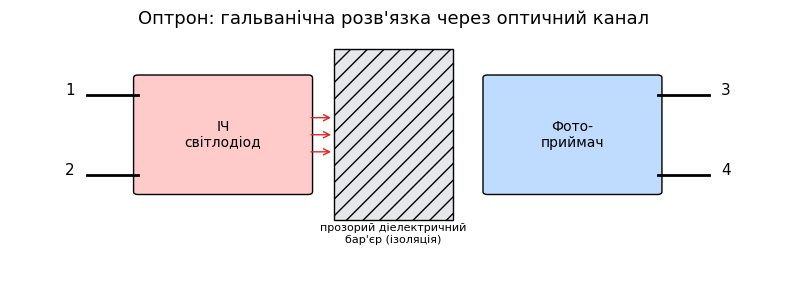

In [8]:
# Схематичне зображення оптрона: випромінювач - оптичний бар'єр - фотоприймач
fig, ax = plt.subplots(figsize=(8, 3))
ax.add_patch(mpatches.FancyBboxPatch((0, 0.5), 2, 2, boxstyle="round,pad=0.05",
                                      facecolor='#fecaca', edgecolor='k'))
ax.text(1, 1.5, 'ІЧ\nсвітлодіод', ha='center', va='center', fontsize=10)
ax.add_patch(mpatches.Rectangle((2.3, 0), 1.4, 3, facecolor='#e5e7eb', edgecolor='k', hatch='//'))
ax.text(3.0, -0.4, "прозорий діелектричний\nбар'єр (ізоляція)", ha='center', fontsize=8)
ax.add_patch(mpatches.FancyBboxPatch((4.1, 0.5), 2, 2, boxstyle="round,pad=0.05",
                                      facecolor='#bfdbfe', edgecolor='k'))
ax.text(5.1, 1.5, 'Фото-\nприймач', ha='center', va='center', fontsize=10)
for y in [1.2, 1.5, 1.8]:
    ax.annotate('', xy=(2.3, y), xytext=(2.0, y), arrowprops=dict(arrowstyle='->', color='#dc2626'))
ax.plot([-0.6, 0], [2.2, 2.2], 'k-'); ax.text(-0.8, 2.2, '1', ha='center')
ax.plot([-0.6, 0], [0.8, 0.8], 'k-'); ax.text(-0.8, 0.8, '2', ha='center')
ax.plot([6.1, 6.7], [2.2, 2.2], 'k-'); ax.text(6.9, 2.2, '3', ha='center')
ax.plot([6.1, 6.7], [0.8, 0.8], 'k-'); ax.text(6.9, 0.8, '4', ha='center')
ax.set_xlim(-1.5, 7.5); ax.set_ylim(-1, 3.3); ax.axis('off')
ax.set_title("Оптрон: гальванічна розв'язка через оптичний канал")
plt.tight_layout(); plt.show()

---
## Терморезистори, варістори та світлодіоди <a class="anchor" id="thermal-varistor-led"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати принцип дії терморезисторів (NTC та PTC) та їхні характеристики
> - Пояснювати принцип дії варістора та його застосування для захисту від перенапруг
> - Пояснювати принцип дії світлодіода та наводити області його застосування

</div>

## Терморезистори <a class="anchor" id="thermistor"></a>

**Терморезистор (термістор)** — це напівпровідниковий резистор, опір якого суттєво (значно сильніше, ніж у металів) залежить від температури. За знаком температурного коефіцієнта опору розрізняють два принципово різні типи.

**NTC-терморезистори** (англ. *Negative Temperature Coefficient*, з від'ємним ТКО) виготовляють із суміші оксидів перехідних металів (Mn, Ni, Co, Fe тощо) методами кераміки. Зі зростанням температури концентрація вільних носіїв заряду в напівпровідниковому матеріалі зростає експоненційно (як і в будь-якому власному/слаболегованому напівпровіднику), тому опір **зменшується** за законом, близьким до

$$R(T) = R_0 \exp\!\left[B\left(\frac{1}{T}-\frac{1}{T_0}\right)\right],$$

де $B$ — коефіцієнт (характеристична температура матеріалу, зазвичай 2000–5000 К), $T$ — абсолютна температура. NTC-термістори застосовують як **датчики температури** (компактні, дешеві, чутливіші за металеві термометри опору) та для **обмеження пускового струму** (у джерелах живлення — послідовно з навантаженням; холодний термістор має великий опір, обмежуючи кидок струму при вмиканні, а після розігріву власним струмом його опір падає й втрати зменшуються).

**PTC-терморезистори** (позистори, з додатним ТКО) на основі легованої полікристалічної кераміки (найчастіше — титанат барію) поводяться інакше: до певної (точки Кюрі) температури опір малий і майже не залежить від $T$, а вище цієї температури (внаслідок зміни кристалічної структури — переходу з сегнетоелектричної фази в параелектричну) опір **різко (на кілька порядків) зростає**. Це дозволяє використовувати PTC-термістори як **самовідновлювані запобіжники** (при перевищенні струму матеріал саморозігрівається, опір зростає, струм обмежується — після охолодження опір знову спадає) та елементи термостабілізації й термозахисту обмоток двигунів.

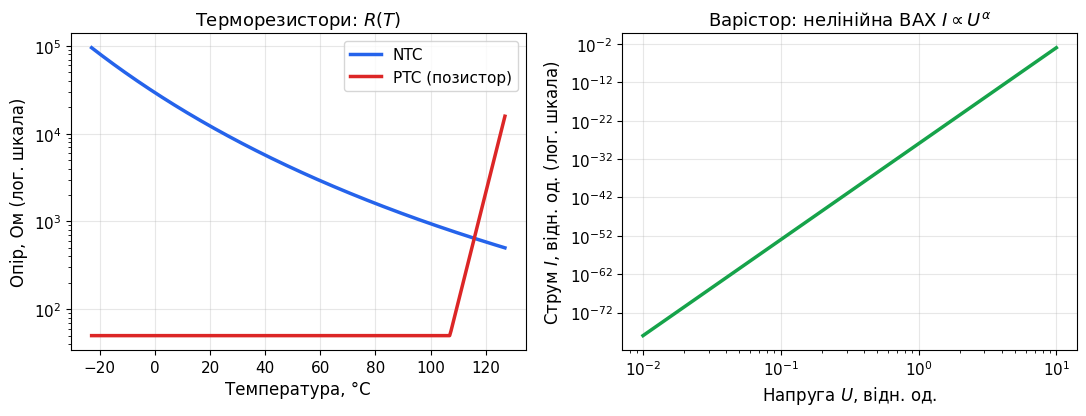

In [9]:
# R(T) для NTC та PTC терморезисторів, ВАХ варістора
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

T = np.linspace(250, 400, 300)
B, R0, T0 = 3500, 10000, 298
R_ntc = R0*np.exp(B*(1/T - 1/T0))
axes[0].semilogy(T-273, R_ntc, color='#2563eb', lw=2.5, label='NTC')

Tc = 380
R_ptc = np.where(T < Tc, 50, 50*10**((T-Tc)/8))
axes[0].semilogy(T-273, R_ptc, color='#dc2626', lw=2.5, label='PTC (позистор)')
axes[0].set_xlabel('Температура, °C'); axes[0].set_ylabel('Опір, Ом (лог. шкала)')
axes[0].set_title('Терморезистори: $R(T)$')
axes[0].legend()

V = np.linspace(0.01, 10, 300)
alpha = 25
I = 1e-3 * V**alpha / 10**alpha
axes[1].loglog(V, I, color='#16a34a', lw=2.5)
axes[1].set_xlabel('Напруга $U$, відн. од.'); axes[1].set_ylabel('Струм $I$, відн. од. (лог. шкала)')
axes[1].set_title('Варістор: нелінійна ВАХ $I \\propto U^{\\alpha}$')
plt.tight_layout(); plt.show()

## Варістори <a class="anchor" id="varistor"></a>

**Варістор** — це напівпровідниковий резистор із **різко нелінійною симетричною** (не залежить від полярності) вольт-амперною характеристикою: за низьких напруг варістор має великий опір (струм через нього незначний, витоку практично немає), а після перевищення певної **класифікаційної напруги** $U_{кл}$ опір різко зменшується, і струм зростає на кілька порядків при незначному подальшому зростанні напруги. ВАХ добре апроксимується степеневим законом

$$I = k\,U^{\alpha}, \qquad \alpha \approx 20-50,$$

тоді як для звичайного лінійного резистора $\alpha=1$. Найпоширеніший сучасний тип — **оксидно-цинковий варістор (MOV, Metal-Oxide Varistor)**: спечена кераміка із зерен ZnO (провідні) розміром у кілька–десятки мкм, розділених тонкими межами зерен, легованими іншими оксидами (Bi₂O₃, Sb₂O₃, Co₂O₃ тощо). Кожна межа зерна поводиться як мікроскопічний зустрічно-послідовний двобар'єрний перехід (подібний до двох зустрічних діодів Шотки); нелінійність усього елемента — результат **паралельно-послідовного** з'єднання мільйонів таких мікропереходів по всьому об'єму кераміки.

**Застосування:** варістори масово застосовують для **захисту від імпульсних перенапруг** — вмикають паралельно з навантаженням/входом живлення; в нормальному режимі (напруга нижча за $U_{кл}$) варістор практично не впливає на коло (великий опір, малий струм витоку), а при виникненні імпульсу перенапруги (грозовий розряд, комутаційний викид, статична електрика) варістор миттєво переходить у низькоомний стан і **шунтує** імпульсну енергію, обмежуючи напругу на захищуваному пристрої безпечним рівнем. Через здатність поглинати значну імпульсну енергію (за короткий час) варістори — основний елемент захисту в мережевих фільтрах, побутових і промислових пристроях захисту від перенапруг (УЗІП/SPD), на входах живлення електронної апаратури.

### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не плутайте знак температурної залежності NTC і PTC термісторів. **NTC** ("N" — negative): опір **спадає** з ростом температури (як у звичайного власного напівпровідника — більше носіїв заряду при нагріванні). **PTC** ("P" — positive), точніше позистор: у робочому діапазоні вище точки Кюрі опір, навпаки, **різко зростає** з температурою — це не "звичайна" напівпровідникова поведінка, а результат структурного фазового переходу в сегнетоелектричній кераміці, тому позистор не можна пояснювати простим ростом концентрації носіїв.

</div>

## Світлодіоди <a class="anchor" id="led"></a>

**Світлодіод** (LED, Light Emitting Diode) — напівпровідниковий діод на основі p-n переходу з **прямозонного** матеріалу (GaAs, GaP, GaN, їх потрійні й четверні тверді розчини), у якому при прямому зміщенні відбувається **інжекційна електролюмінесценція**: неосновні носії, інжектовані через перехід (електрони в p-область, дірки в n-область), рекомбінують із основними носіями **безпосередньо** (без участі фонона, оскільки мінімум зони провідності та максимум валентної зони припадають на одне й те саме значення хвильового вектора), випромінюючи енергію у вигляді фотона з енергією, близькою до ширини забороненої зони:

$$h\nu \approx E_g \quad\Rightarrow\quad \lambda_{max}\,[\text{нм}] \approx \frac{1240}{E_g\,[\text{еВ}]}.$$

Саме тому колір випромінювання світлодіода визначається **матеріалом** (шириною забороненої зони), а не якимось зовнішнім фільтром:

| Матеріал | $E_g$, еВ | Колір / $\lambda$ |
|---|---|---|
| GaAs | 1,42 | ІЧ, ≈870 нм |
| AlGaInP | 1,9–2,2 | червоний/жовтогарячий, 600–650 нм |
| GaP:N | ≈2,2 | зелений, ≈565 нм |
| InGaN | 2,6–3,4 | синій, ≈450 нм; у комбінації з жовтим люмінофором → білий |
| AlGaN / GaN | 3,4+ | ближній УФ |

На відміну від звичайного випрямного діода, конструкція світлодіода оптимізована на **виведення** якомога більшої частки згенерованих фотонів назовні (форма кристала й корпусу-лінзи, що зменшує повне внутрішнє відбиття, дзеркальні шари, що відбивають випромінювання від підкладки назовні). **Області застосування:** індикація та світлова сигналізація, загальне й архітектурне освітлення (сучасні білі світлодіоди — основа енергоефективного освітлення завдяки світловіддачі, що на порядок перевищує лампи розжарювання), підсвітка дисплеїв, оптичні лінії зв'язку невеликої дальності, інфрачервоні випромінювачі для пультів ДК та оптронів (розглянутих вище).

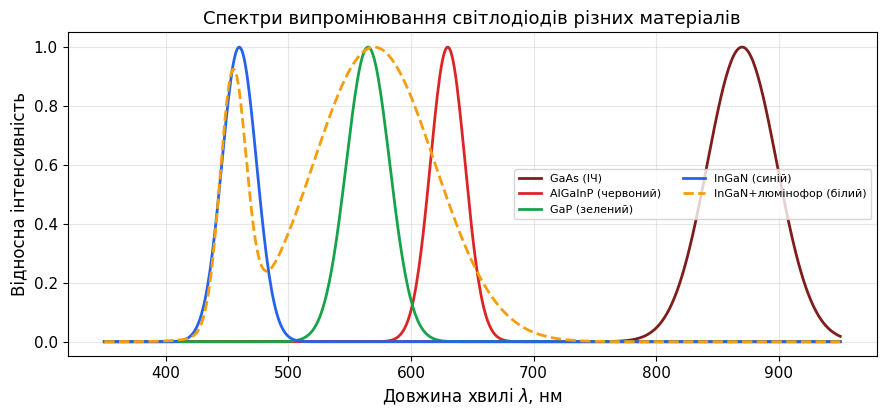

In [10]:
# Спектр випромінювання світлодіодів різних матеріалів (ілюстративні гаусові контури)
fig, ax = plt.subplots(figsize=(9, 4.3))
lam = np.linspace(350, 950, 600)
leds = [('GaAs (ІЧ)', 870, 40, '#7f1d1d'), ('AlGaInP (червоний)', 630, 20, '#dc2626'),
        ('GaP (зелений)', 565, 25, '#16a34a'), ('InGaN (синій)', 460, 20, '#2563eb'),
        ('InGaN+люмінофор (білий)', None, None, None)]
for name, mu, sigma, color in leds[:-1]:
    S = np.exp(-((lam-mu)/sigma)**2)
    ax.plot(lam, S, color=color, lw=2, label=name)
white = 0.6*np.exp(-((lam-455)/15)**2) + 0.7*np.exp(-((lam-570)/70)**2)
ax.plot(lam, white/white.max(), color='#f59e0b', lw=2, ls='--', label='InGaN+люмінофор (білий)')
ax.set_xlabel('Довжина хвилі $\\lambda$, нм'); ax.set_ylabel('Відносна інтенсивність')
ax.set_title('Спектри випромінювання світлодіодів різних матеріалів')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Явище електролюмінесценції в карбіді кремнію вперше спостерігав британський радіоінженер **Генрі Джозеф Раунд** ще 1907 р., а ґрунтовно дослідив і опублікував радянський вчений **Олег Лосєв** у 1920-х рр. Проте практично придатний, яскравий і відтворюваний світлодіод видимого діапазону (червоний, на основі GaAsP) створив у 1962 р. американський інженер **Нік Голоняк** (Nick Holonyak Jr.), якого називають "батьком світлодіода". "Останньою барвою" стали ефективні **сині** світлодіоди на основі GaN, розроблені Ісаму Акасакі, Хіроші Амано та Шуджі Накамурою в 1990-х — саме синій колір відкрив шлях до створення білих світлодіодів для освітлення, за що винахідники отримали **Нобелівську премію з фізики 2014 р.**

</div>

### ⚡ Практичне застосування: Захист електроніки від перенапруг

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Оксидно-цинкові варістори та оптрони — типові приклади того, як напівпровідникові прилади убезпечують електронні системи. Варістори, увімкнені паралельно з входом живлення побутових приладів, мережевих фільтрів і промислових контролерів, поглинають енергію грозових і комутаційних імпульсних перенапруг, не пропускаючи небезпечний викид напруги до чутливої електроніки. Оптрони (симісторного типу) в тих самих системах забезпечують гальванічну розв'язку між мікроконтролером (низька напруга) і силовим колом (мережева напруга) — типова архітектура "розумної" розетки чи твердотільного реле поєднує обидва прилади.

</div>

### ✅ Питання для самоперевірки: Оптоелектронні, теплові прилади та варістори

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> У чому принципова відмінність фотогальванічного й фотодіодного режимів роботи фотодіода?</summary>

> **Відповідь:** У фотогальванічному режимі зовнішньої напруги немає ($U=0$), і сам перехід є джерелом фотоЕРС (як сонячний елемент) — повільніший і менш лінійний спосіб. У фотодіодному режимі до переходу прикладена зворотна напруга, яка розширює область збіднення (зменшуючи ємність і підвищуючи швидкодію) і забезпечує майже лінійну залежність фотоструму від освітленості в широкому діапазоні.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому колір випромінювання світлодіода визначається матеріалом кристала, а не, наприклад, кольором корпусу?</summary>

> **Відповідь:** Випромінювання виникає внаслідок прямої міжзонної рекомбінації інжектованих носіїв, при якій енергія фотона дорівнює ширині забороненої зони матеріалу ($h\nu \approx E_g$). Оскільки $E_g$ — фіксована властивість конкретного напівпровідникового сполучення, довжина хвилі (а отже й колір) визначається саме матеріалом; забарвлений корпус може лише додатково фільтрувати або розсіювати світло, але не змінює довжину хвилі випромінювання самого кристала.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому варістор у нормальному режимі роботи мережі майже не споживає струму, а при імпульсній перенапрузі різко "відкривається"?</summary>

> **Відповідь:** ВАХ варістора описується різко нелінійним степеневим законом $I \propto U^{\alpha}$ з $\alpha \approx 20$–$50$. Поки напруга нижча за класифікаційну $U_{кл}$, струм через мільйони мікроскопічних потенціальних бар'єрів на межах зерен ZnO мізерно малий. Щойно напруга перевищує $U_{кл}$ (наприклад, унаслідок імпульсу), струм зростає на кілька порядків при незначному подальшому зростанні напруги — саме ця різка нелінійність і дозволяє варістору ефективно шунтувати імпульсну енергію.

</details>

---

## Підсумок курсу: Електронні прилади та мікроелектроніка <a class="anchor" id="course-summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Конспект охоплює три взаємопов'язані частини курсу:

| Частина | Файл | Зміст |
|---|---|---|
| **1. Основи теорії та напівпровідникові діоди** | `Лекція_1_Основи_теорії_та_напівпровідникові_діоди.ipynb` | Зонна теорія, власні й домішкові напівпровідники, p-n перехід, ідеальна й реальна ВАХ діода, тунельний і лавинний пробій, випрямні діоди, діоди Шотки, стабілітрони |
| **2. Біполярні та польові транзистори** | `Лекція_2_Біполярні_та_польові_транзистори.ipynb` | Структура й режими біполярного транзистора, схеми включення, статичні й частотні характеристики, пробій, польові транзистори з керуючим переходом та з ізольованим затвором, їх характеристики та імпульсна робота |
| **3. Інші напівпровідникові прилади** | `Лекція_3_Інші_напівпровідникові_прилади.ipynb` (цей файл) | Прилади із зарядним зв'язком, диністори, тиристори, симістори, способи їх вмикання/вимикання, IGBT-транзистори, фоторезистори, фотодіоди, оптрони, терморезистори, варістори, світлодіоди |

### Загальна логіка курсу

Усі розглянуті прилади базуються на **керуванні рухом і рекомбінацією носіїв заряду** в неоднорідно легованому або структурно неоднорідному напівпровіднику:
1. **Один p-n перехід** (діод) → випрямлення, стабілізація напруги, фотоперетворення, випромінювання світла — залежно від режиму зміщення й особливостей матеріалу/конструкції.
2. **Два p-n переходи** (біполярний транзистор, польовий транзистор з керуючим переходом) → підсилення та керування струмом/напругою за рахунок взаємодії двох переходів або зміни перерізу провідного каналу.
3. **Три й більше переходів** (тиристорні прилади, IGBT) → регенеративне (лавиноподібне) перемикання та потужне силове керування, що поєднує властивості біполярних і польових структур.
4. **Спеціалізовані структури** (МДН-конденсатор у ПЗЗ, неоднорідна кераміка в терморезисторах і варісторах) → перетворення й обробка сигналів на нетипових для "класичного" p-n переходу фізичних принципах.

</div>

---

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*